You are given the root of a binary tree root. Invert the binary tree and return its root.

Example 1:

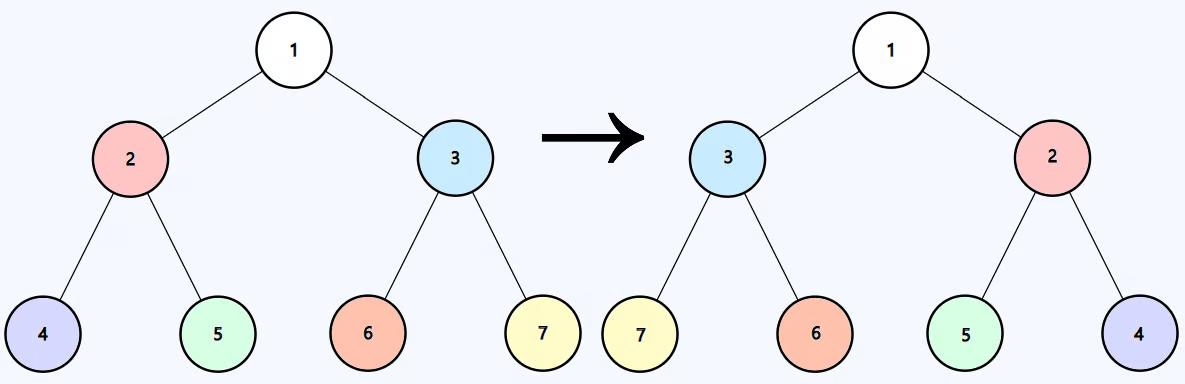

Input: root = [1,2,3,4,5,6,7]

Output: [1,3,2,7,6,5,4]

Example 2:

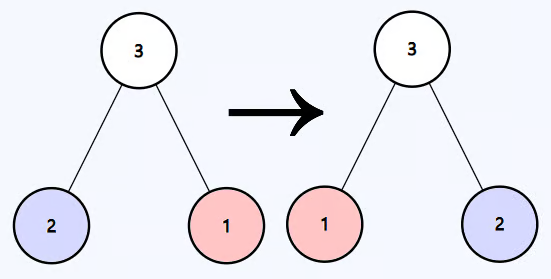

Input: root = [3,2,1]

Output: [3,1,2]

Example 3:

Input: root = []

Output: []

In [2]:
from typing import Optional

In [15]:
# Definition for a binary tree node.
class TreeNode:
    def __init__(self, val=0, left=None, right=None):
        self.val = val
        self.left = left
        self.right = right

class Solution:
    def invertTree(self, root: Optional[TreeNode]) -> Optional[TreeNode]:
        print("--- Recursive ---")
        if not root:
            return None
        root.left, root.right = self.invertTree(root.right), self.invertTree(root.left)
        return root

In [18]:
root = TreeNode(4)
root.left        = TreeNode(2)
root.right       = TreeNode(7)
root.left.left   = TreeNode(1)
root.left.right  = TreeNode(3)
root.right.left  = TreeNode(6)
root.right.right = TreeNode(9)

# --- invert ---
solution = Solution()
inverted = solution.invertTree(root)

# --- helper to print tree level by level ---
from collections import deque

def print_tree(root):
    if not root:
        print("Empty tree")
        return
    queue = deque([root])
    while queue:
        node = queue.popleft()
        print(node.val, end=" ")
        if node.left:  queue.append(node.left)
        if node.right: queue.append(node.right)
    print()

print_tree(inverted)  # 4 7 2 9 6 3 1

--- DFS ---
--- DFS ---
--- DFS ---
--- DFS ---
--- DFS ---
--- DFS ---
--- DFS ---
--- DFS ---
--- DFS ---
--- DFS ---
--- DFS ---
--- DFS ---
--- DFS ---
--- DFS ---
--- DFS ---
4 7 2 9 6 3 1 


# BFS

Intuition

To invert (mirror) a binary tree, every node must swap its left and right children. Using Breadth-First Search (BFS), we process the tree level-by-level:

Start from the root.

For each node, swap its children.

Then push the (new) left and right children into the queue.

Continue until every node has been processed.

This approach ensures that every node is visited exactly once and inverted immediately when encountered.

Algorithm

If the tree is empty, return null.

Initialize a queue and insert the root node.

While the queue is not empty:

Remove the front node.

Swap its left and right children.

If the left child exists, add it to the queue.

If the right child exists, add it to the queue.

After all nodes are processed, return the root as the inverted tree.


In [ ]:
# Iteration
# Time Complexity: O(n)
# Space Complexity: O(n)
class Solution:
    def invertTree(self, root: Optional[TreeNode]) -> Optional[TreeNode]:
        print("--- BFS ---")
        if not root:
            return None
        queue = deque([root])
        while queue:
            node = queue.popleft()
            node.left, node.right = node.right, node.left
            if node.left:
                queue.append(node.left)
            if node.right:
                queue.append(node.right)
        return root

# DFS

Intuition

Inverting a binary tree means swapping every node’s left and right subtree.

With Depth-First Search (DFS), we use recursion to invert the tree in a top-down manner:

At each node, swap the left and right children.

Then recursively invert the left subtree.

Recursively invert the right subtree.

Because every subtree is itself a smaller binary tree, recursion naturally handles this structure.

The inversion happens during the descent of the recursion, and each subtree becomes correctly mirrored.

Algorithm

If the current node is null, return null.

Swap the node's left and right pointers.

Recursively call dfs on the new left child.

Recursively call dfs on the new right child.

Return the current node (now inverted).

In [ ]:
# Iteration
# Time Complexity: O(n)
# Space Complexity: O(n)
class Solution:
    def invertTree(self, root: Optional[TreeNode]) -> Optional[TreeNode]:
        print("--- DFS ---")

        if not root: return None

        root.left, root.right = root.right, root.left

        self.invertTree(root.left)
        self.invertTree(root.right)

        return root

# Iterative DFS

Intuition

Iterative DFS inverts a binary tree using an explicit stack instead of recursion.

The idea is the same as recursive DFS:

Visit a node.

Swap its left and right children.

Continue the process for its children.

But instead of the call stack, we use our own stack data structure.

The process is:

Push the root into the stack.

Pop the top node, swap its children.

Push its children onto the stack (if they exist).

Continue until the stack is empty.

This simulates the recursive DFS in an iterative manner and works well when recursion depth may be too large.

Algorithm

If root is null, return null.

Initialize a stack with root.

While stack is not empty:

Pop a node.

Swap its left and right pointers.

If the left child exists, push it to the stack.

If the right child exists, push it to the stack.

Return the root.

In [ ]:
# Iteration
# Time Complexity: O(n)
# Space Complexity: O(n)
class Solution:
    def invertTree(self, root: Optional[TreeNode]) -> Optional[TreeNode]:
        print("--- Iterative ---")
        if not root:
            return None
        stack = [root]
        while stack:
            node = stack.pop()
            node.left, node.right = node.right, node.left
            if node.left:
                stack.append(node.left)
            if node.right:
                stack.append(node.right)
        return root